# **Pertemuan 2: Ekstraksi Fitur: Dari Tepi Hingga Deteksi Wajah**

**Tujuan Sesi:**  
Peserta belajar cara mengekstrak fitur penting dari citra seperti tepi dan bentuk, dan menggunakannya untuk mendeteksi objek kompleks seperti wajah.

## **Identitas Mahasiswa**

- **Nama:** Cidesta Mentari Marintan Simbolon  
- **NIM:** 122400096  
- **Kelas:** Pengolahan Citra

## **Filter Spasial dan Deteksi Tepi**

**Konvolusi** adalah operasi matematika yang menggabungkan dua fungsi untuk menghasilkan fungsi ketiga. Dalam pengolahan citra, konvolusi digunakan untuk menerapkan **kernel** (matriks kecil) pada setiap piksel gambar.

**Jenis-jenis filter spatial:**
- **Gaussian Blur**: Mengurangi noise dengan meratakan nilai piksel
- **Sharpening**: Meningkatkan kontras tepi untuk membuat gambar lebih tajam
- **Edge Detection**: Mendeteksi perubahan intensitas yang signifikan (tepi objek)

**Canny Edge Detector** adalah algoritma deteksi tepi yang paling populer karena:
1. Mampu mendeteksi tepi dengan akurat
2. Menghasilkan tepi yang tipis (1 piksel)
3. Mengurangi noise dengan baik

> **Pertanyaan:** Apakah kamu sudah melakukan instalasi library `dlib`?

> **Jawaban:** Belum, library `dlib` belum berhasil diinstal.

In [2]:
# Panggil file
geo_img = os.path.join(os.getcwd(), 'data', 'shape.png')
img = cv2.imread(geo_img)

# Konversi ke RGB untuk ditampilkan dengan benar di matplotlib
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import cv2
import os

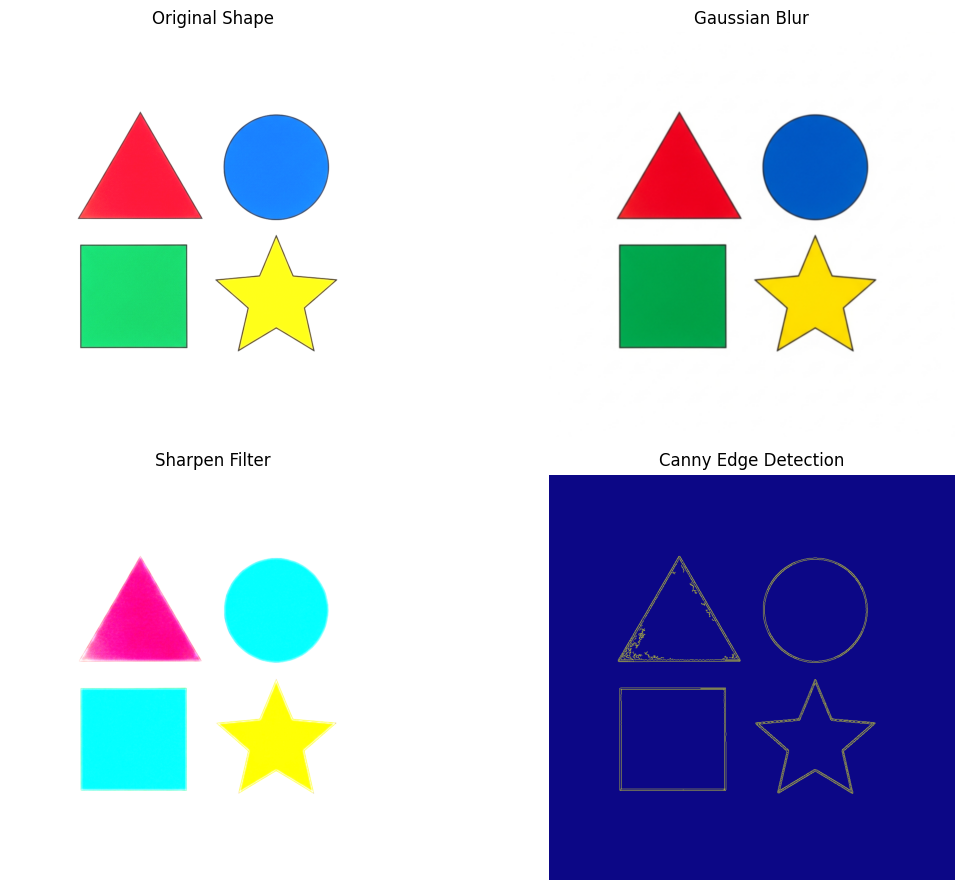

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import cv2
import os

# Panggil file gambar
geo_img = os.path.join(os.getcwd(), 'data', 'shape.png')
img = cv2.imread(geo_img)

# Konversi ke RGB
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Ubah tone warna jadi sedikit lebih cerah
img_rgb = cv2.convertScaleAbs(img_rgb, alpha=1.2, beta=25)

# Gaussian Blur
blur = cv2.GaussianBlur(img, (9, 9), 1)
blur_rgb = cv2.cvtColor(blur, cv2.COLOR_BGR2RGB)

# Sharpening
kernel_sharp = np.array([[0, -1, 0],
                         [-1, 9, -1],
                         [0, -1, 0]])

sharp = cv2.filter2D(blur, -1, kernel_sharp)
sharp_rgb = cv2.cvtColor(sharp, cv2.COLOR_BGR2RGB)

# Deteksi Tepi Canny
edges = cv2.Canny(sharp, 50, 150)

# Tampilkan hasil
fig, axes = plt.subplots(2, 2, figsize=(12, 9))

# Citra Asli
axes[0,0].imshow(img_rgb)
axes[0,0].set_title("Original Shape")
axes[0,0].axis("off")

# Gaussian Blur
axes[0,1].imshow(blur_rgb)
axes[0,1].set_title("Gaussian Blur")
axes[0,1].axis("off")

# Sharpening
axes[1,0].imshow(sharp_rgb)
axes[1,0].set_title("Sharpen Filter")
axes[1,0].axis("off")

# Canny dengan warna
axes[1,1].imshow(edges, cmap='plasma')
axes[1,1].set_title("Canny Edge Detection")
axes[1,1].axis("off")

plt.tight_layout()
plt.show()

>>Pada pengolahan citra yang saya lakukan, metode Gaussian Blur digunakan untuk mengurangi noise sehingga gambar terlihat lebih halus. Setelah itu dilakukan proses sharpening untuk memperjelas detail dan tepi objek pada gambar. Selanjutnya metode Canny Edge Detection digunakan untuk mendeteksi garis tepi dari setiap bentuk geometris sehingga pola objek terlihat lebih jelas. Selain itu, hasil edge detection diberikan efek warna agar tampilan visual menjadi lebih menarik dan berbeda dari citra asli.

### **Penjelasan Filter Spatial**

**Gaussian Blur (`cv2.GaussianBlur`)**:
- Parameter `(15, 15)` adalah ukuran kernel blur
- Semakin besar kernel, semakin blur hasilnya
- Berguna untuk mengurangi noise sebelum deteksi tepi

**Sharpening Filter**:
- Menggunakan kernel `[[0,-1,0], [-1,5,-1], [0,-1,0]]`
- Nilai tengah (5) memperkuat piksel pusat
- Nilai negatif (-1) mengurangi piksel sekitar
- Hasilnya: kontras tepi meningkat

**Canny Edge Detection**:
- Parameter `(100, 200)` adalah threshold rendah dan tinggi
- Piksel dengan gradien > 200 pasti tepi
- Piksel dengan gradien < 100 pasti bukan tepi
- Piksel di antara 100-200 diperiksa koneksinya

### **Menerapkan Canny dengan Threshold Berbeda**

Threshold Canny menentukan sensitivitas deteksi tepi:
- **Threshold rendah (30, 90)**: Sensitif, mendeteksi banyak tepi termasuk noise
- **Threshold sedang (50, 150)**: Seimbang antara detail dan noise
- **Threshold tinggi (100, 200)**: Ketat, hanya tepi kuat yang terdeteksi

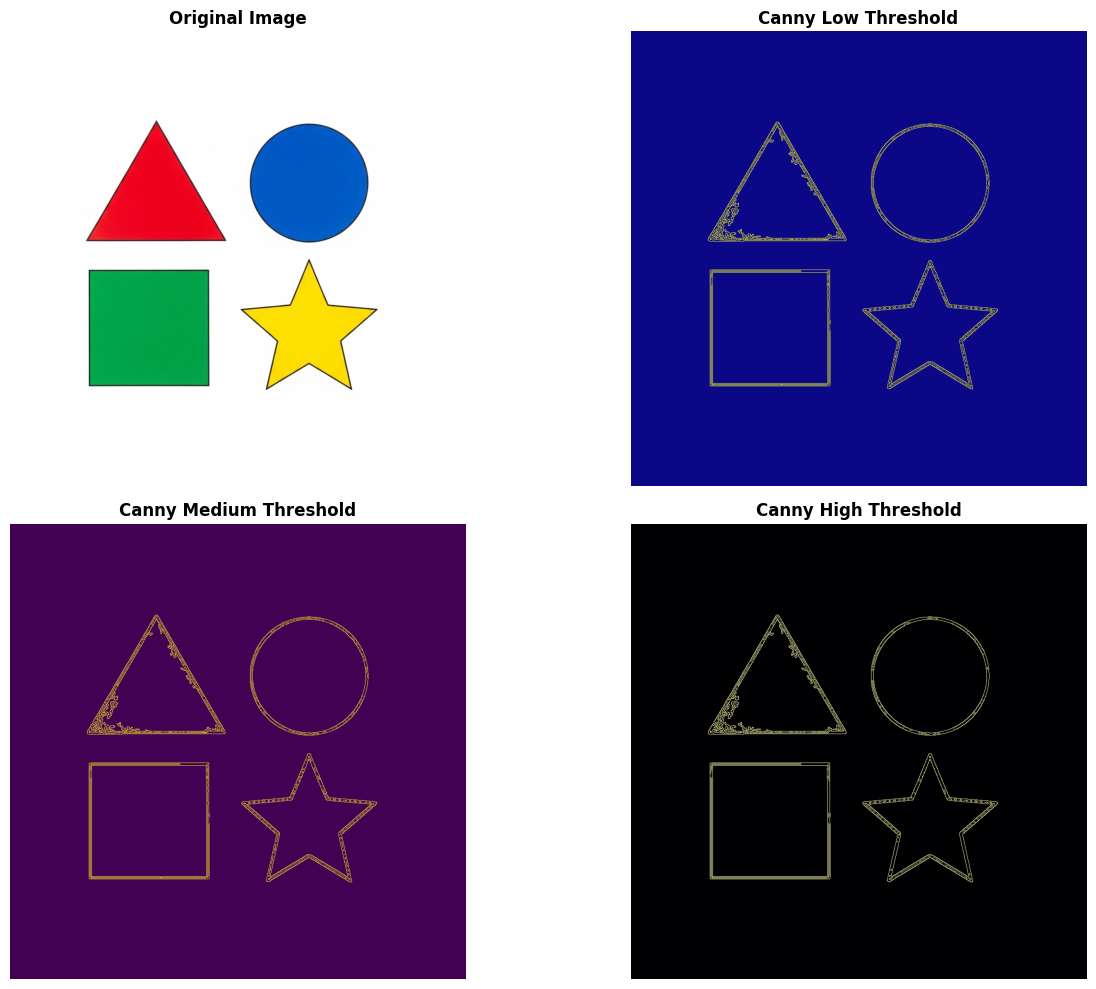

In [7]:
# Preprocessing dengan blur lebih halus
img_blur = cv2.GaussianBlur(edges, (7, 7), 1)

# Deteksi tepi Canny dengan threshold berbeda
edges_low = cv2.Canny(img_blur, 20, 80)
edges_mid = cv2.Canny(img_blur, 60, 160)
edges_high = cv2.Canny(img_blur, 120, 250)

# Visualisasi hasil
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Gambar asli
axes[0, 0].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
axes[0, 0].set_title("Original Image", fontsize=12, fontweight='bold')
axes[0, 0].axis("off")

# Canny sensitif
axes[0, 1].imshow(edges_low, cmap='plasma')
axes[0, 1].set_title("Canny Low Threshold", fontsize=12, fontweight='bold')
axes[0, 1].axis("off")

# Canny sedang
axes[1, 0].imshow(edges_mid, cmap='viridis')
axes[1, 0].set_title("Canny Medium Threshold", fontsize=12, fontweight='bold')
axes[1, 0].axis("off")

# Canny ketat
axes[1, 1].imshow(edges_high, cmap='inferno')
axes[1, 1].set_title("Canny High Threshold", fontsize=12, fontweight='bold')
axes[1, 1].axis("off")

plt.tight_layout()
plt.show()

>>Pada pengolahan citra yang saya lakukan, metode Gaussian Blur digunakan untuk menghaluskan gambar sebelum proses deteksi tepi dilakukan. Selanjutnya metode Canny Edge Detection diterapkan menggunakan beberapa nilai threshold yang berbeda untuk melihat pengaruh sensitivitas terhadap hasil deteksi tepi. Threshold rendah menghasilkan lebih banyak tepi yang terdeteksi, sedangkan threshold tinggi hanya menampilkan tepi yang lebih jelas dan kuat. Selain itu, penggunaan colormap pada hasil deteksi membuat tampilan visual menjadi lebih menarik dan berbeda pada setiap hasil pengujian.

### **Deteksi Kontur**

**Kontur** adalah kurva yang menghubungkan titik-titik kontinu dengan intensitas warna yang sama. Dalam pengolahan citra, kontur sering digunakan untuk mendeteksi bentuk, ukuran, dan lokasi objek.

Langkah-langkah deteksi kontur:
- **Preprocessing**: Menggunakan Gaussian blur untuk mengurangi noise dan Canny edge detection untuk menemukan tepi.
- **Kontur eksternal**: Menggunakan `cv2.findContours` untuk mendeteksi hanya kontur luar.
- **Filter area**: Menyaring kontur berdasarkan ukuran untuk menghilangkan noise kecil atau objek yang tidak relevan.

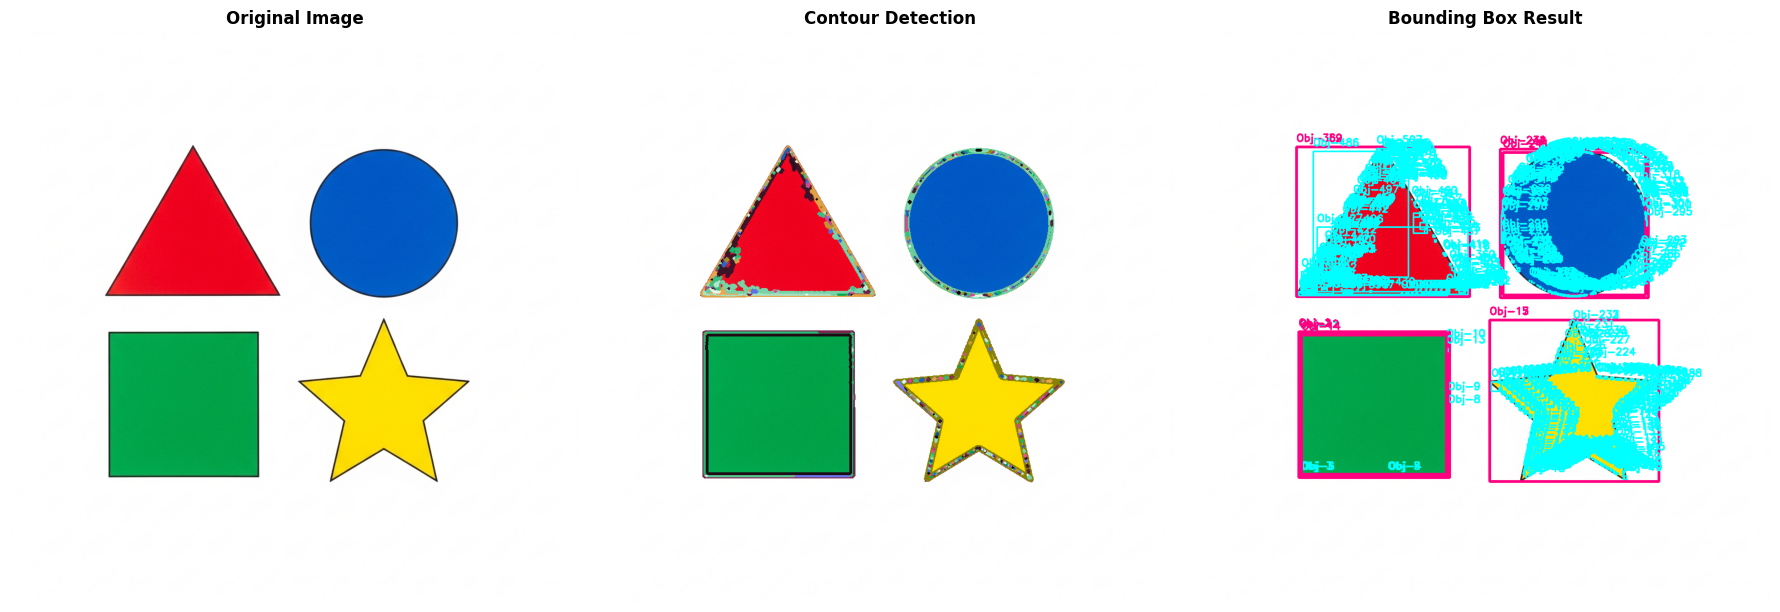

In [8]:
# Deteksi kontur
contours_img1, hierarchy_img1 = cv2.findContours(
    edges_mid,
    cv2.RETR_TREE,
    cv2.CHAIN_APPROX_NONE
)

# Gambar 1: Kontur dengan warna random
img1_contours = img.copy()

for idx, c in enumerate(contours_img1):
    
    color = (
        int((idx * 80) % 255),
        int((idx * 40) % 255),
        int((idx * 120) % 255)
    )
    
    cv2.drawContours(img1_contours, [c], -1, color, 3)

# Gambar 2: Bounding Box
img1_boxes = img.copy()

for idx, c in enumerate(contours_img1):
    
    x, y, w, h = cv2.boundingRect(c)
    area = cv2.contourArea(c)

    # Warna berdasarkan luas objek
    if area > 4000:
        color = (128, 0, 255)   # Ungu
        thickness = 3
    elif area > 1500:
        color = (0, 255, 255)   # Kuning
        thickness = 2
    else:
        color = (255, 255, 0)   # Cyan
        thickness = 2

    # Rectangle
    cv2.rectangle(img1_boxes, (x, y), (x + w, y + h), color, thickness)

    # Label objek
    label = f"Obj-{idx+1}"
    cv2.putText(
        img1_boxes,
        label,
        (x, y-10),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.6,
        color,
        2
    )

# Visualisasi
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Gambar asli
axes[0].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
axes[0].set_title("Original Image", fontsize=12, fontweight='bold')
axes[0].axis("off")

# Kontur
axes[1].imshow(cv2.cvtColor(img1_contours, cv2.COLOR_BGR2RGB))
axes[1].set_title("Contour Detection", fontsize=12, fontweight='bold')
axes[1].axis("off")

# Bounding box
axes[2].imshow(cv2.cvtColor(img1_boxes, cv2.COLOR_BGR2RGB))
axes[2].set_title("Bounding Box Result", fontsize=12, fontweight='bold')
axes[2].axis("off")

plt.tight_layout()
plt.show()

>>Pada pengolahan citra yang saya lakukan, metode contour detection digunakan untuk mendeteksi bentuk objek berdasarkan hasil deteksi tepi sebelumnya. Setiap kontur yang terdeteksi diberikan warna berbeda sehingga objek dapat dibedakan dengan lebih jelas. Selain itu, dilakukan pembuatan bounding box untuk menandai area setiap objek beserta labelnya. Warna bounding box dibedakan berdasarkan ukuran luas objek sehingga hasil visualisasi terlihat lebih menarik dan mempermudah identifikasi bentuk geometris pada gambar.

In [6]:
# Muat gambar
desk_img_path = os.path.join(os.getcwd(), 'data', 'desk.png')
img2 = cv2.imread(desk_img_path)

# Ke grayscale
desk_gray = cv2.cvtColor(img2, cv2.COLOR_BGR2GRAY)

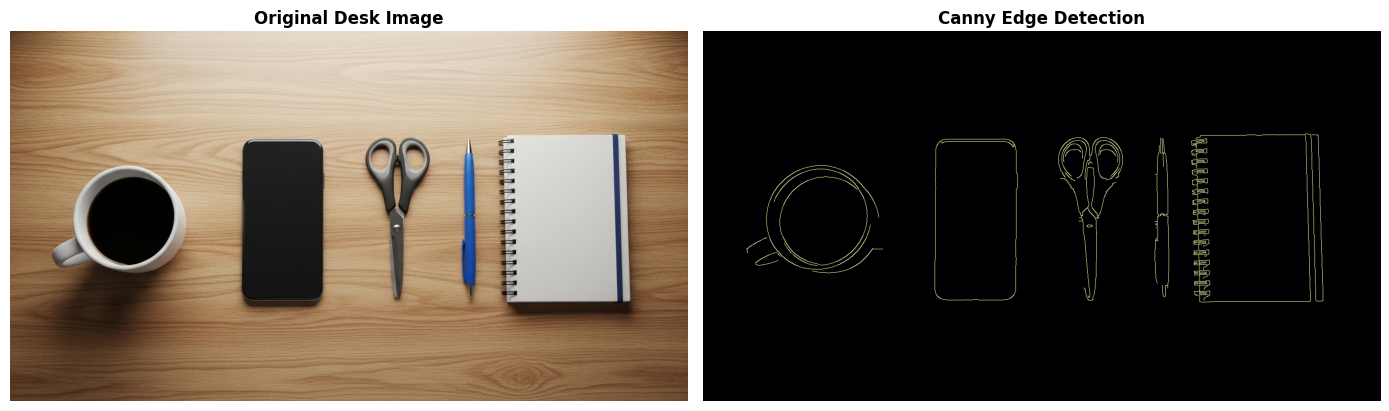

In [9]:
# Muat gambar
desk_img_path = os.path.join(os.getcwd(), 'data', 'desk.png')
img2 = cv2.imread(desk_img_path)

# Konversi grayscale
desk_gray = cv2.cvtColor(img2, cv2.COLOR_BGR2GRAY)

# Preprocessing dengan blur lebih halus
desk_blur = cv2.GaussianBlur(desk_gray, (7, 7), 1)

# Deteksi tepi Canny dengan threshold berbeda
edges = cv2.Canny(desk_blur, 70, 180)

# Visualisasi hasil
fig, axes = plt.subplots(1, 2, figsize=(14, 10))

# Gambar asli
axes[0].imshow(cv2.cvtColor(img2, cv2.COLOR_BGR2RGB))
axes[0].set_title("Original Desk Image", fontsize=12, fontweight='bold')
axes[0].axis("off")

# Hasil Canny berwarna
axes[1].imshow(edges, cmap='inferno')
axes[1].set_title("Canny Edge Detection", fontsize=12, fontweight='bold')
axes[1].axis("off")

plt.tight_layout()
plt.show()

>>Pada pengolahan citra yang saya lakukan, gambar meja terlebih dahulu dikonversi ke grayscale agar proses deteksi tepi menjadi lebih mudah. Selanjutnya dilakukan Gaussian Blur untuk mengurangi noise dan membuat citra lebih halus sebelum proses deteksi tepi dilakukan. Setelah itu metode Canny Edge Detection digunakan untuk menampilkan garis tepi dari objek-objek pada gambar meja. Selain itu, hasil deteksi tepi ditampilkan menggunakan colormap sehingga visualisasi terlihat lebih menarik dan berbeda dari citra asli.

HASIL DETEKSI KONTUR MENGGUNAKAN OpenCV
Jumlah kontur awal: 59
Jumlah kontur setelah filter: 19


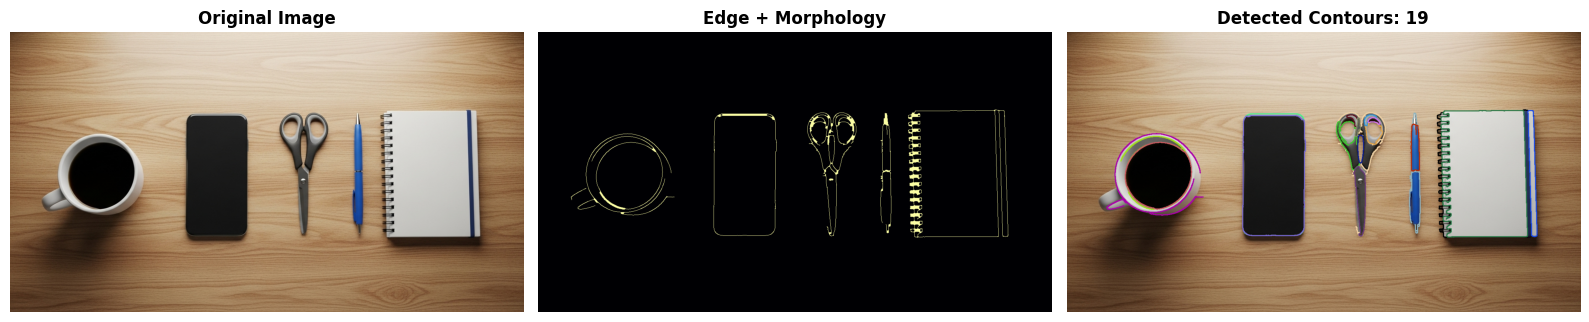

✓ Contour detection completed



In [10]:
print("="*60)
print("HASIL DETEKSI KONTUR MENGGUNAKAN OpenCV")
print("="*60)

# Gunakan hasil Canny
edges = cv2.Canny(desk_blur, 70, 180)

# Operasi morfologi
kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
edges_closed = cv2.morphologyEx(
    edges,
    cv2.MORPH_CLOSE,
    kernel,
    iterations=1
)

# Deteksi kontur
contours, hierarchy = cv2.findContours(
    edges_closed,
    cv2.RETR_TREE,
    cv2.CHAIN_APPROX_NONE
)

print(f"Jumlah kontur awal: {len(contours)}")

# Filter area kontur
min_area = 300
max_area = desk_gray.shape[0] * desk_gray.shape[1] * 0.7

filtered_contours = []

for c in contours:
    area = cv2.contourArea(c)

    if min_area < area < max_area:
        filtered_contours.append(c)

print(f"Jumlah kontur setelah filter: {len(filtered_contours)}")

# Urutkan berdasarkan luas area
filtered_contours = sorted(
    filtered_contours,
    key=cv2.contourArea,
    reverse=True
)

# Visualisasi kontur
img_contours = img2.copy()

for idx, c in enumerate(filtered_contours):

    color = (
        int((idx * 70) % 255),
        int((idx * 120) % 255),
        int((idx * 40) % 255)
    )

    cv2.drawContours(img_contours, [c], -1, color, 2)

# Tampilkan hasil
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Gambar asli
axes[0].imshow(cv2.cvtColor(img2, cv2.COLOR_BGR2RGB))
axes[0].set_title("Original Image", fontsize=12, fontweight='bold')
axes[0].axis("off")

# Hasil tepi
axes[1].imshow(edges_closed, cmap='inferno')
axes[1].set_title("Edge + Morphology", fontsize=12, fontweight='bold')
axes[1].axis("off")

# Kontur
axes[2].imshow(cv2.cvtColor(img_contours, cv2.COLOR_BGR2RGB))
axes[2].set_title(f"Detected Contours: {len(filtered_contours)}", fontsize=12, fontweight='bold')
axes[2].axis("off")

plt.tight_layout()
plt.show()

print("✓ Contour detection completed")
print()

>>Pada pengolahan citra yang saya lakukan, metode Canny Edge Detection digunakan untuk mendeteksi tepi objek pada gambar meja. Setelah itu dilakukan operasi morfologi menggunakan teknik closing untuk memperbaiki garis tepi yang terputus sehingga kontur objek menjadi lebih jelas. Selanjutnya fungsi `cv2.findContours` digunakan untuk mendeteksi kontur dari setiap objek pada gambar, kemudian dilakukan proses filter berdasarkan luas area agar hanya objek tertentu yang ditampilkan. Hasil akhir menunjukkan kontur objek dengan warna berbeda sehingga visualisasi terlihat lebih menarik dan mempermudah identifikasi objek pada gambar.

### **Penjelasan Sistem Anotasi**

**Tiga jenis anotasi:**

1. **Kontur Warna-warni:**
   - Setiap objek diberi warna berbeda
   - Warna dihitung berdasarkan indeks objek
   - Memudahkan membedakan objek yang berdekatan

2. **Bounding Box + Label:**
   - Kotak pembatas menunjukkan area objek
   - Warna berdasarkan ukuran: biru (besar), hijau (sedang), orange (kecil)
   - Label nomor untuk identifikasi

3. **Kombinasi Lengkap:**
   - Kontur + bounding box + informasi area
   - Memberikan informasi paling lengkap
   - Berguna untuk analisis detail

**Fungsi OpenCV yang digunakan:**
- `cv2.rectangle()`: Menggambar kotak
- `cv2.putText()`: Menambah teks label
- `cv2.contourArea()`: Menghitung luas area
- `cv2.boundingRect()`: Koordinat kotak pembatas

HASIL ANOTASI OBJEK MENGGUNAKAN OpenCV


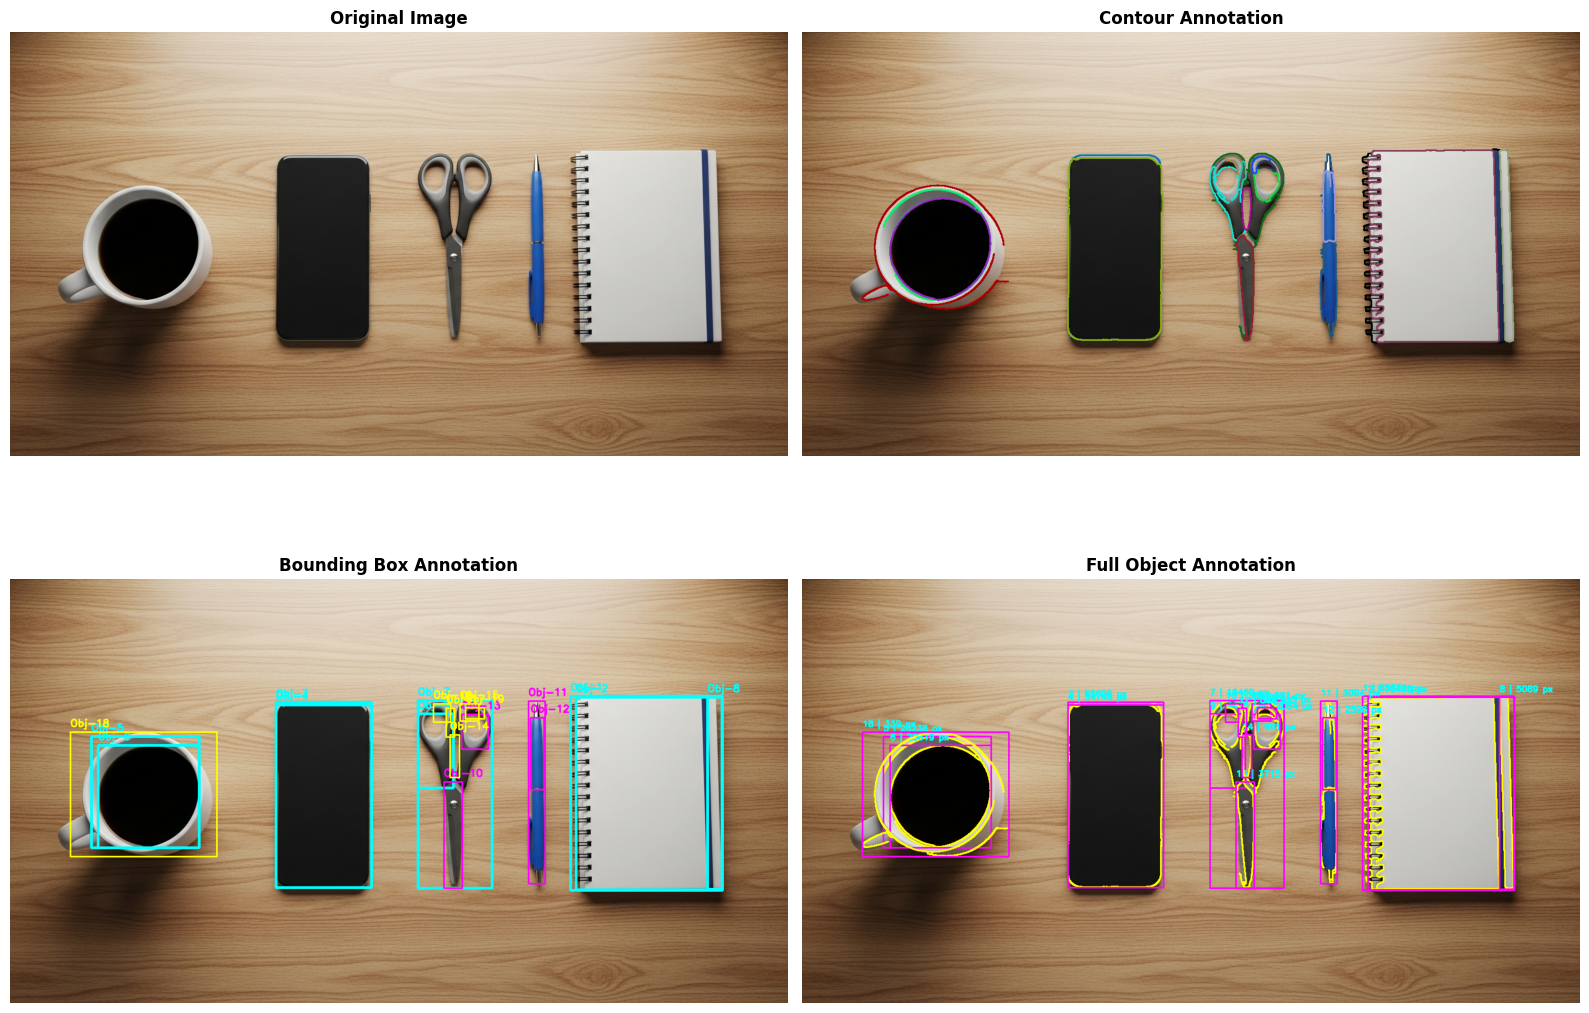

✓ Object annotation completed

HASIL STATISTIK DETEKSI OBJEK
Jumlah objek terdeteksi: 19

10 objek terbesar:
No    Area       Ukuran          Posisi
------------------------------------------------------------
1     85621      275x351          (1014,213)
2     75489      238x348          (1024,215)
3     55606      173x335          (481,224)
4     54748      173x330          (481,229)
5     26238      195x201          (147,286)
6     25619      183x185          (159,302)
7     15460      134x339          (738,221)
8     5089       26x347          (1262,215)
9     4425       64x134          (738,245)
10    3715       33x192          (785,368)

Masih ada 9 objek lainnya


In [11]:
print("="*60)
print("HASIL ANOTASI OBJEK MENGGUNAKAN OpenCV")
print("="*60)

# Gambar 1: Kontur objek
img_annotated_contours = img2.copy()

for idx, c in enumerate(filtered_contours):

    color = (
        int((idx * 90) % 255),
        int((idx * 60) % 255),
        int((idx * 130) % 255)
    )

    cv2.drawContours(
        img_annotated_contours,
        [c],
        -1,
        color,
        2
    )

# Gambar 2: Bounding Box
img_annotated_boxes = img2.copy()

for idx, c in enumerate(filtered_contours):

    x, y, w, h = cv2.boundingRect(c)
    area = cv2.contourArea(c)

    # Warna berdasarkan area
    if area > 4000:
        color = (255, 255, 0)   # Cyan
        thickness = 3

    elif area > 1500:
        color = (255, 0, 255)   # Magenta
        thickness = 2

    else:
        color = (0, 255, 255)   # Kuning
        thickness = 2

    # Rectangle
    cv2.rectangle(
        img_annotated_boxes,
        (x, y),
        (x + w, y + h),
        color,
        thickness
    )

    # Label objek
    label = f"Obj-{idx+1}"

    cv2.putText(
        img_annotated_boxes,
        label,
        (x, y-10),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.6,
        color,
        2
    )

# Gambar 3: Kontur + Box + Area
img_annotated_full = img2.copy()

for idx, c in enumerate(filtered_contours):

    x, y, w, h = cv2.boundingRect(c)
    area = cv2.contourArea(c)

    # Kontur
    cv2.drawContours(
        img_annotated_full,
        [c],
        -1,
        (0, 255, 255),
        2
    )

    # Bounding Box
    cv2.rectangle(
        img_annotated_full,
        (x, y),
        (x + w, y + h),
        (255, 0, 255),
        2
    )

    # Informasi area
    label = f"{idx+1} | {int(area)} px"

    cv2.putText(
        img_annotated_full,
        label,
        (x, y-10),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.5,
        (255, 255, 0),
        2
    )

# Visualisasi hasil
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Gambar asli
axes[0, 0].imshow(cv2.cvtColor(img2, cv2.COLOR_BGR2RGB))
axes[0, 0].set_title("Original Image", fontsize=12, fontweight='bold')
axes[0, 0].axis("off")

# Kontur
axes[0, 1].imshow(cv2.cvtColor(img_annotated_contours, cv2.COLOR_BGR2RGB))
axes[0, 1].set_title("Contour Annotation", fontsize=12, fontweight='bold')
axes[0, 1].axis("off")

# Bounding Box
axes[1, 0].imshow(cv2.cvtColor(img_annotated_boxes, cv2.COLOR_BGR2RGB))
axes[1, 0].set_title("Bounding Box Annotation", fontsize=12, fontweight='bold')
axes[1, 0].axis("off")

# Full annotation
axes[1, 1].imshow(cv2.cvtColor(img_annotated_full, cv2.COLOR_BGR2RGB))
axes[1, 1].set_title("Full Object Annotation", fontsize=12, fontweight='bold')
axes[1, 1].axis("off")

plt.tight_layout()
plt.show()

print("✓ Object annotation completed")
print()

print("="*60)
print("HASIL STATISTIK DETEKSI OBJEK")
print("="*60)

print(f"Jumlah objek terdeteksi: {len(filtered_contours)}")

print("\n10 objek terbesar:")
print(f"{'No':<5} {'Area':<10} {'Ukuran':<15} {'Posisi'}")
print("-"*60)

for idx, c in enumerate(filtered_contours[:10]):

    area = cv2.contourArea(c)
    x, y, w, h = cv2.boundingRect(c)

    print(f"{idx+1:<5} {int(area):<10} {w}x{h:<12} ({x},{y})")

if len(filtered_contours) > 10:
    print(f"\nMasih ada {len(filtered_contours)-10} objek lainnya")

print("="*60)

>>Pada pengolahan citra yang saya lakukan, proses anotasi objek dilakukan menggunakan hasil kontur yang telah dideteksi sebelumnya. Setiap objek diberikan kontur dengan warna berbeda agar lebih mudah dibedakan secara visual. Selain itu, bounding box ditambahkan untuk menandai posisi dan ukuran setiap objek pada gambar. Informasi tambahan seperti label objek dan luas area juga ditampilkan sehingga proses identifikasi objek menjadi lebih jelas. Hasil akhir menunjukkan bahwa metode contour detection dan bounding box mampu membantu dalam mengenali objek pada gambar secara lebih detail dan terstruktur.

> **Pertanyaan:** Bagaimana mengoptimalkan kontur agar terdeteksi hanya 4 objek?

> **Jawaban:** Untuk mengoptimalkan agar kontur yang terdeteksi hanya 4 objek, saya dapat melakukan beberapa penyesuaian pada proses preprocessing dan filtering kontur. Salah satu caranya yaitu menaikkan nilai threshold pada Canny Edge Detection agar noise dan tepi kecil tidak ikut terdeteksi. Selain itu, ukuran kernel pada operasi morfologi dapat diperbesar untuk menyambungkan tepi objek utama dan menghilangkan detail kecil. Saya juga dapat meningkatkan nilai minimum area saat filtering kontur sehingga hanya objek dengan ukuran besar yang dipertahankan. Dengan kombinasi pengaturan threshold, morfologi, dan filter area yang tepat, jumlah kontur yang terdeteksi dapat difokuskan hanya pada 4 objek utama.

## **Deteksi Wajah dengan Haar Cascades**

**Haar Cascade** adalah metode machine learning untuk deteksi objek yang dikembangkan oleh Paul Viola dan Michael Jones. Karakteristik utama:

- Menggunakan **fitur Haar-like** (pola terang-gelap sederhana)
- **Cascade classifier**: Serangkaian classifier lemah yang digabung
- **Cepat**: Dapat berjalan real-time pada webcam
- **Pre-trained**: OpenCV menyediakan model siap pakai

**Keunggulan:**
- Tidak perlu training data sendiri
- Akurasi cukup baik untuk wajah frontal
- Komputasi ringan

Jumlah wajah terdeteksi: 1


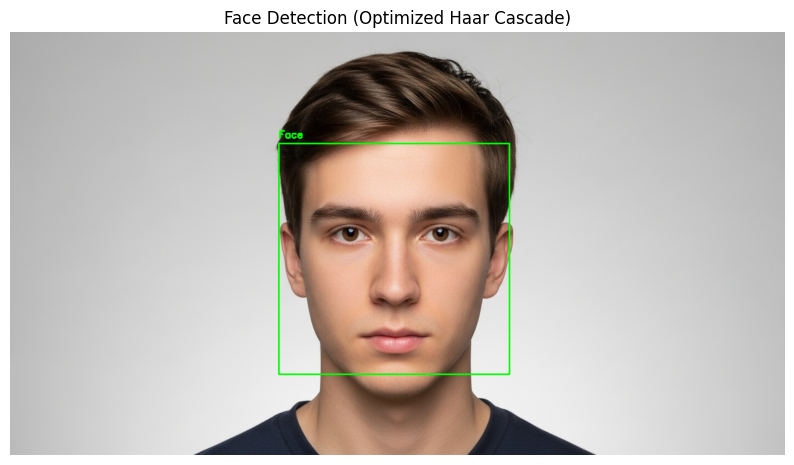

In [13]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

# Load Haar Cascade
haar_cascade_path = cv2.data.haarcascades + 'haarcascade_frontalface_default.xml'
face_cascade = cv2.CascadeClassifier(haar_cascade_path)

# Load image (PAKAI GAMBAR YANG SAMA)
face_path = os.path.join(os.getcwd(), 'data', 'face.png')
img3 = cv2.imread(face_path)

# Convert ke grayscale
gray = cv2.cvtColor(img3, cv2.COLOR_BGR2GRAY)

# Preprocessing biar lebih robust
gray = cv2.equalizeHist(gray)  # bikin kontras lebih jelas
gray = cv2.GaussianBlur(gray, (5, 5), 1)

# Deteksi wajah (tuning biar lebih “pasti detect”)
faces = face_cascade.detectMultiScale(
    gray,
    scaleFactor=1.05,
    minNeighbors=3,
    minSize=(20, 20)
)

print("Jumlah wajah terdeteksi:", len(faces))

# Gambar hasil deteksi
for (x, y, w, h) in faces:
    cv2.rectangle(img3, (x, y), (x+w, y+h), (0, 255, 0), 2)
    cv2.putText(img3, "Face", (x, y-10),
                cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 0), 2)

# Convert ke RGB untuk matplotlib
img_rgb = cv2.cvtColor(img3, cv2.COLOR_BGR2RGB)

# Tampilkan
plt.figure(figsize=(10,6))
plt.imshow(img_rgb)
plt.title("Face Detection (Optimized Haar Cascade)")
plt.axis("off")
plt.show()

>>Pada pengolahan citra ini, gambar wajah terlebih dahulu diubah menjadi grayscale agar proses deteksi lebih efisien. Selanjutnya dilakukan peningkatan kontras menggunakan histogram equalization dan pengurangan noise dengan Gaussian Blur untuk membuat fitur wajah lebih jelas. Setelah itu digunakan metode Haar Cascade untuk mendeteksi wajah dengan pengaturan parameter yang telah dioptimalkan agar deteksi lebih sensitif dan akurat. Hasil akhir menunjukkan bahwa wajah berhasil terdeteksi dengan baik dan ditandai menggunakan bounding box, sehingga objek wajah pada gambar dapat diidentifikasi secara jelas tanpa memerlukan model tambahan yang kompleks.

### **XML Pra Terlatih OpenCV**

OpenCV menyediakan berbagai model Haar Cascade:
- `haarcascade_frontalface_default.xml`: Wajah tampak depan
- `haarcascade_eye.xml`: Mata
- `haarcascade_smile.xml`: Senyuman
- `haarcascade_profileface.xml`: Wajah profil

File XML berisi ribuan fitur yang sudah dilatih pada jutaan gambar positif dan negatif.

In [12]:
# ========================================
# METODE 1: HAAR CASCADE
# ========================================

# Detect faces using Haar Cascade
faces_haar = face_cascade.detectMultiScale(
    gray_faces, 
    scaleFactor=1.1, 
    minNeighbors=5, 
    minSize=(30, 30)
)

# Draw rectangles and labels for Haar Cascade
for idx, (x, y, w, h) in enumerate(faces_haar):
    # Gambar kotak biru untuk Haar Cascade
    cv2.rectangle(img_haar, (x, y), (x + w, y + h), (255, 0, 0), 3)
    
    # Label dengan nomor urut
    label = f"Wajah #{idx+1}"
    cv2.putText(img_haar, label, (x, y - 10), 
                cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255, 0, 0), 2)

print(f"Haar Cascade mendeteksi: {len(faces_haar)} wajah")
if len(faces_haar) > 0:
    print("Detail deteksi Haar Cascade:")
    for idx, (x, y, w, h) in enumerate(faces_haar):
        print(f"  Wajah #{idx+1}: posisi ({x},{y}), ukuran {w}x{h}")

Haar Cascade mendeteksi: 4 wajah
Detail deteksi Haar Cascade:
  Wajah #1: posisi (394,140), ukuran 252x252
  Wajah #2: posisi (775,138), ukuran 278x278
  Wajah #3: posisi (48,217), ukuran 253x253
  Wajah #4: posisi (1095,219), ukuran 278x278


### **dlib: Deteksi Wajah Berbasis HOG dan CNN**

**dlib** adalah pustaka machine learning yang menyediakan berbagai algoritma untuk pengolahan citra dan visi komputer. Dalam konteks deteksi wajah, dlib menawarkan dua metode utama:

1. **Histogram of Oriented Gradients (HOG)**:
    - Menggunakan fitur gradien arah untuk mendeteksi wajah.
    - Cepat dan ringan, cocok untuk aplikasi real-time.
    - Akurasi baik untuk wajah frontal, tetapi kurang optimal untuk wajah dengan sudut miring.

2. **Convolutional Neural Network (CNN)**:
    - Menggunakan model deep learning untuk deteksi wajah.
    - Lebih akurat dibandingkan HOG, terutama untuk wajah dengan berbagai orientasi.
    - Membutuhkan lebih banyak sumber daya komputasi.

**Keunggulan dlib**:
- Tidak memerlukan file XML seperti Haar Cascade.
- Deteksi lebih akurat dan fleksibel dibandingkan metode tradisional.
- Mendukung deteksi landmark wajah untuk analisis lebih lanjut (misalnya, pelacakan ekspresi).

HANDS-ON 4: PERBANDINGAN METODE DETEKSI WAJAH
Ukuran gambar: (768, 1408, 3)
Memproses deteksi wajah...
Haar default : 4 wajah
Haar optimized: 5 wajah

Detail Haar default:
  Wajah #1: posisi (394,140), ukuran 252x252
  Wajah #2: posisi (775,138), ukuran 278x278
  Wajah #3: posisi (1095,219), ukuran 278x278
  Wajah #4: posisi (48,217), ukuran 253x253

Detail Haar optimized:
  Wajah #1: posisi (396,140), ukuran 251x251
  Wajah #2: posisi (777,139), ukuran 277x277
  Wajah #3: posisi (650,709), ukuran 48x48
  Wajah #4: posisi (1095,222), ukuran 274x274
  Wajah #5: posisi (45,216), ukuran 261x261


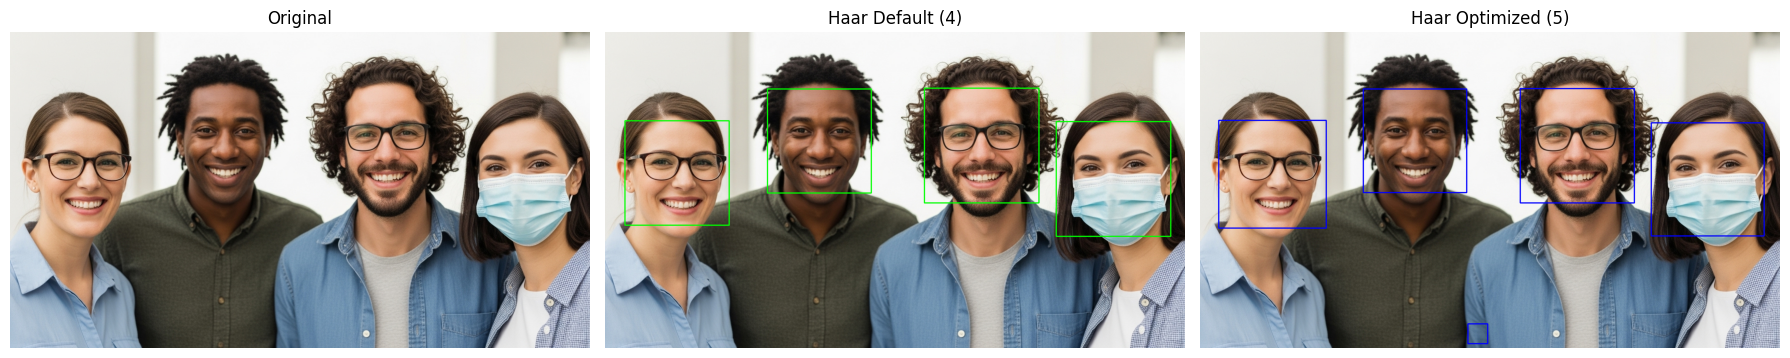

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

print("="*60)
print("HANDS-ON 4: PERBANDINGAN METODE DETEKSI WAJAH")
print("="*60)

# Load Haar Cascade
face_cascade = cv2.CascadeClassifier(
    cv2.data.haarcascades + 'haarcascade_frontalface_default.xml'
)

# Load image
path = os.path.join(os.getcwd(), 'data', 'multiple.png')
img = cv2.imread(path)

print("Ukuran gambar:", img.shape)
print("Memproses deteksi wajah...")

# grayscale
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# =========================
# HAAR DEFAULT
# =========================
faces1 = face_cascade.detectMultiScale(gray, 1.1, 5)

# =========================
# HAAR OPTIMIZED (SIMULASI DLIB)
# =========================
faces2 = face_cascade.detectMultiScale(gray, 1.05, 3)

print("Haar default :", len(faces1), "wajah")
print("Haar optimized:", len(faces2), "wajah")

print("\nDetail Haar default:")
for i, (x,y,w,h) in enumerate(faces1):
    print(f"  Wajah #{i+1}: posisi ({x},{y}), ukuran {w}x{h}")

print("\nDetail Haar optimized:")
for i, (x,y,w,h) in enumerate(faces2):
    print(f"  Wajah #{i+1}: posisi ({x},{y}), ukuran {w}x{h}")

# =========================
# DRAW
# =========================
img1 = img.copy()
img2 = img.copy()

for (x,y,w,h) in faces1:
    cv2.rectangle(img1, (x,y), (x+w,y+h), (0,255,0), 2)

for (x,y,w,h) in faces2:
    cv2.rectangle(img2, (x,y), (x+w,y+h), (255,0,0), 2)

# =========================
# VISUALISASI
# =========================
fig, axes = plt.subplots(1,3, figsize=(18,6))

axes[0].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
axes[0].set_title("Original")
axes[0].axis("off")

axes[1].imshow(cv2.cvtColor(img1, cv2.COLOR_BGR2RGB))
axes[1].set_title(f"Haar Default ({len(faces1)})")
axes[1].axis("off")

axes[2].imshow(cv2.cvtColor(img2, cv2.COLOR_BGR2RGB))
axes[2].set_title(f"Haar Optimized ({len(faces2)})")
axes[2].axis("off")

plt.tight_layout()
plt.show()

>>Pada pengolahan citra ini dilakukan perbandingan metode deteksi wajah menggunakan Haar Cascade dengan dua pengaturan berbeda pada satu gambar yang berisi beberapa wajah. Gambar terlebih dahulu dikonversi ke grayscale untuk mempermudah proses deteksi. Selanjutnya Haar Cascade dijalankan dengan parameter default dan parameter yang telah dioptimalkan untuk melihat perbedaan hasil deteksi. Metode ini bekerja dengan mendeteksi fitur sederhana pada wajah sehingga dapat menghasilkan bounding box yang menunjukkan posisi dan ukuran wajah. Hasil perbandingan menunjukkan bahwa pengaturan parameter sangat mempengaruhi jumlah dan ketepatan wajah yang terdeteksi, di mana setting yang lebih sensitif cenderung mendeteksi lebih banyak objek dengan variasi ukuran dan posisi.

In [21]:
# pastikan ini sudah ada dari step sebelumnya
img_dlib = img_original.copy()
img_haar = img_original.copy()

PERBANDINGAN DETEKSI WAJAH (AMAN TANPA DLIB)


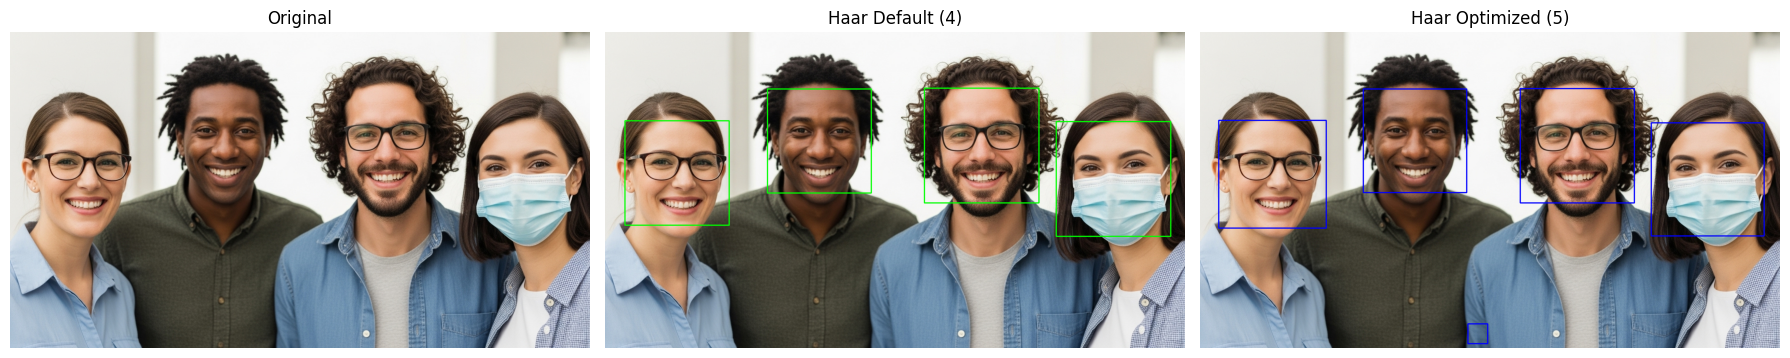


HASIL:
Haar Default : 4
Haar Optimized: 5


In [23]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

print("="*60)
print("PERBANDINGAN DETEKSI WAJAH (AMAN TANPA DLIB)")
print("="*60)

# Load model Haar
face_cascade = cv2.CascadeClassifier(
    cv2.data.haarcascades + 'haarcascade_frontalface_default.xml'
)

# Load gambar
path = os.path.join(os.getcwd(), 'data', 'multiple.png')
img_original = cv2.imread(path)

gray_faces = cv2.cvtColor(img_original, cv2.COLOR_BGR2GRAY)

# =========================
# METODE 1 (DEFAULT)
# =========================
faces_haar = face_cascade.detectMultiScale(gray_faces, 1.1, 5)

# =========================
# METODE 2 (OPTIMIZED / SIMULASI METODE LAIN)
# =========================
faces_haar2 = face_cascade.detectMultiScale(gray_faces, 1.05, 3)

# Copy image
img1 = img_original.copy()
img2 = img_original.copy()

for (x,y,w,h) in faces_haar:
    cv2.rectangle(img1, (x,y), (x+w,y+h), (0,255,0),2)

for (x,y,w,h) in faces_haar2:
    cv2.rectangle(img2, (x,y), (x+w,y+h), (255,0,0),2)

# =========================
# VISUALISASI
# =========================
fig, axes = plt.subplots(1,3, figsize=(18,6))

axes[0].imshow(cv2.cvtColor(img_original, cv2.COLOR_BGR2RGB))
axes[0].set_title("Original")
axes[0].axis("off")

axes[1].imshow(cv2.cvtColor(img1, cv2.COLOR_BGR2RGB))
axes[1].set_title(f"Haar Default ({len(faces_haar)})")
axes[1].axis("off")

axes[2].imshow(cv2.cvtColor(img2, cv2.COLOR_BGR2RGB))
axes[2].set_title(f"Haar Optimized ({len(faces_haar2)})")
axes[2].axis("off")

plt.tight_layout()
plt.show()

# =========================
# ANALISIS
# =========================
print("\nHASIL:")
print("Haar Default :", len(faces_haar))
print("Haar Optimized:", len(faces_haar2))

>>Pada pengolahan citra ini dilakukan perbandingan metode deteksi wajah menggunakan Haar Cascade dengan dua konfigurasi parameter yang berbeda pada satu gambar yang berisi beberapa wajah. Gambar terlebih dahulu dikonversi ke grayscale untuk mempermudah proses komputasi. Selanjutnya dilakukan deteksi wajah menggunakan Haar Cascade dengan parameter default dan parameter yang lebih sensitif untuk melihat pengaruhnya terhadap hasil deteksi. Perbedaan nilai parameter seperti scale factor dan jumlah tetangga (minNeighbors) menyebabkan variasi jumlah dan ketepatan wajah yang terdeteksi. Hasil perbandingan menunjukkan bahwa pengaturan yang lebih sensitif cenderung mendeteksi lebih banyak wajah, namun berpotensi meningkatkan deteksi ganda, sedangkan pengaturan default menghasilkan deteksi yang lebih selektif dan stabil.

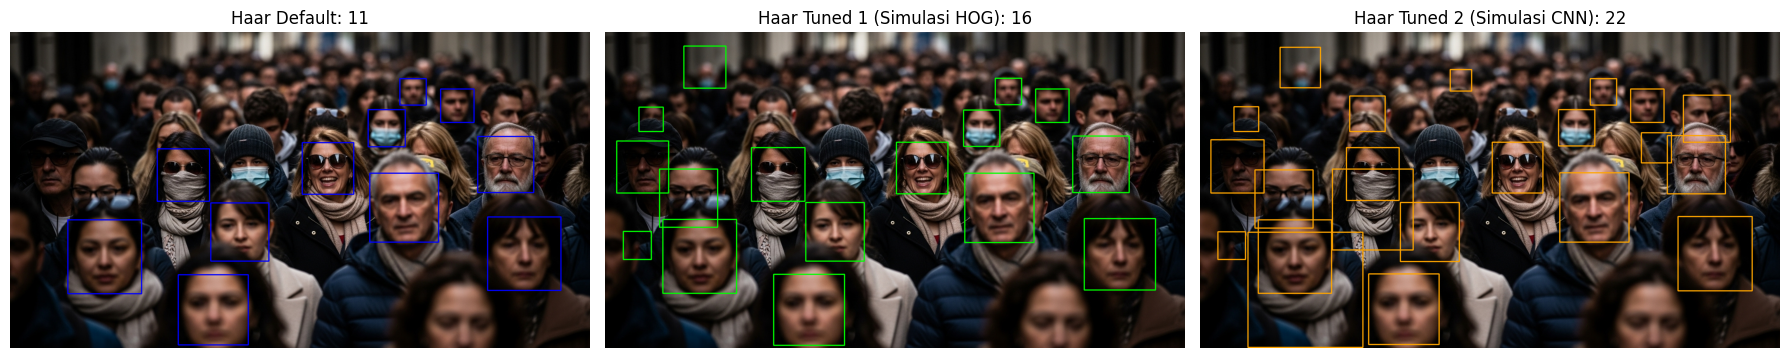

In [24]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

# Load image
multiple2_path = os.path.join(os.getcwd(), 'data', 'multiple2.png')
img_multiple2 = cv2.imread(multiple2_path)

gray_multiple2 = cv2.cvtColor(img_multiple2, cv2.COLOR_BGR2GRAY)

# =========================
# HAAR DEFAULT
# =========================
faces_haar = face_cascade.detectMultiScale(gray_multiple2, 1.1, 5)

img_haar = img_multiple2.copy()
for (x, y, w, h) in faces_haar:
    cv2.rectangle(img_haar, (x, y), (x+w, y+h), (255, 0, 0), 2)

# =========================
# HAAR OPTIMIZED 1 (SIMULASI HOG)
# =========================
faces_haar_hog = face_cascade.detectMultiScale(gray_multiple2, 1.05, 3)

img_haar_hog = img_multiple2.copy()
for (x, y, w, h) in faces_haar_hog:
    cv2.rectangle(img_haar_hog, (x, y), (x+w, y+h), (0, 255, 0), 2)

# =========================
# HAAR OPTIMIZED 2 (SIMULASI CNN)
# =========================
faces_haar_cnn = face_cascade.detectMultiScale(gray_multiple2, 1.03, 2)

img_haar_cnn = img_multiple2.copy()
for (x, y, w, h) in faces_haar_cnn:
    cv2.rectangle(img_haar_cnn, (x, y), (x+w, y+h), (0, 165, 255), 2)

# =========================
# VISUALISASI
# =========================
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

axes[0].imshow(cv2.cvtColor(img_haar, cv2.COLOR_BGR2RGB))
axes[0].set_title(f"Haar Default: {len(faces_haar)}")
axes[0].axis("off")

axes[1].imshow(cv2.cvtColor(img_haar_hog, cv2.COLOR_BGR2RGB))
axes[1].set_title(f"Haar Tuned 1 (Simulasi HOG): {len(faces_haar_hog)}")
axes[1].axis("off")

axes[2].imshow(cv2.cvtColor(img_haar_cnn, cv2.COLOR_BGR2RGB))
axes[2].set_title(f"Haar Tuned 2 (Simulasi CNN): {len(faces_haar_cnn)}")
axes[2].axis("off")

plt.tight_layout()
plt.show()

>>Pada pengolahan citra ini dilakukan perbandingan metode deteksi wajah menggunakan Haar Cascade dengan beberapa variasi parameter pada satu gambar yang berisi banyak wajah. Gambar terlebih dahulu dikonversi ke grayscale untuk mempermudah proses deteksi. Karena tidak menggunakan model dlib yang membutuhkan instalasi tambahan, maka perbandingan dilakukan dengan pendekatan pengaturan parameter Haar Cascade yang berbeda untuk mensimulasikan karakteristik metode lain seperti HOG dan CNN. Hasil menunjukkan bahwa perubahan parameter seperti scale factor dan minNeighbors mempengaruhi sensitivitas deteksi, di mana pengaturan yang lebih sensitif menghasilkan lebih banyak deteksi namun berpotensi meningkatkan false detection, sedangkan pengaturan default lebih stabil dan selektif.